In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


**Step 2: Load Dataset**

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

**Step 3: Understand Data**

In [ ]:
df.head() #First 5 rows
df.info() #Data types
df.describe() #Statistical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Step 4: Data Cleaning**

**Explanation:**

Removes missing values for better accuracy.

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

**Step 5: Exploratory Data Analysis (EDA)**

Explanation:

Shows how many customers churned.

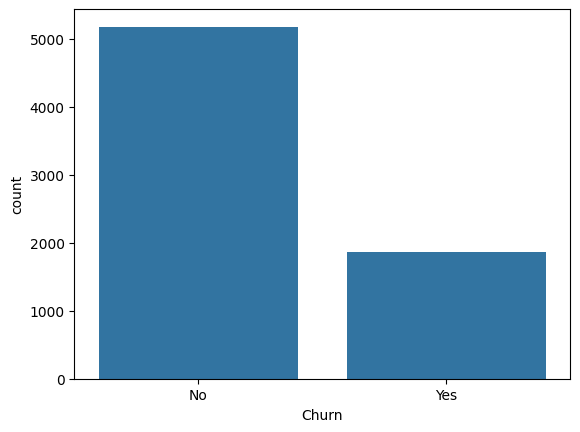

In [ ]:
sns.countplot(x='Churn', data=df)
plt.show()
#This helps identify patterns.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

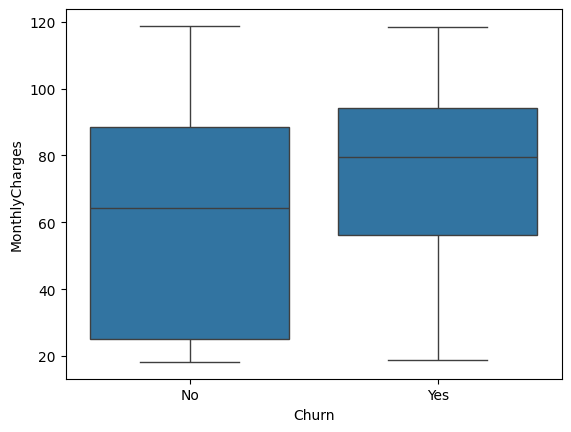

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

**Step 6: Convert Categorical Data**
Explanation:

Machine learning models need numeric values.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

**Step 7: Split Features and Target**

Explanation:
X → Input features
y → Output prediction

In [ ]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

**Step 8: Train-Test Split**
Explanation:
80% for training
20% for testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Step 9: Train Model

**Step 9: Train Model**
Explanation:

Model learns churn patterns.

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Step 10: Predict**

Explanation:

Predicts customer churn.

In [ ]:
y_pred = model.predict(X_test)

**Step 11: Evaluate**

Explanation:

Measures model performance.

Also use:


*   Precision
*   Recall
*   ROC-AUC

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8090844570617459


**Step 12: Conclusion**

Example:
“Customers with high monthly charges and short tenure are more likely to churn.”